# Notebook 02 — Feature Engineering
**Project:** Unlocking Behavioral Intelligence in Airline Loyalty Programs  
**Purpose:** Build member-level features from the 2017-2018 flight activity window that capture behavioral patterns — these features feed directly into the churn model and segmentation in notebooks 03 and 04.


## 1. Imports & load cleaned data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE     = Path.home() / "airline-loyalty-intelligence"
PROC     = BASE / "data" / "processed"
FIG_DIR  = BASE / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

lh = pd.read_csv(PROC / "loyalty_history_clean.csv", parse_dates=["enrollment_date"])
fa = pd.read_csv(PROC / "flight_activity_clean.csv", parse_dates=["Date"])

print(f"Loyalty History  : {lh.shape}")
print(f"Flight Activity  : {fa.shape}")
print("Loaded successfully.")


Loyalty History  : (16737, 20)
Flight Activity  : (392936, 9)
Loaded successfully.


## 2. Base activity aggregates
Start with simple totals per member across the full 2017-2018 window.

In [3]:
base = fa.groupby("Loyalty Number").agg(
    total_flights       = ("Total Flights",        "sum"),
    total_distance      = ("Distance",             "sum"),
    total_pts_acc       = ("Points Accumulated",   "sum"),
    total_pts_red       = ("Points Redeemed",      "sum"),
    total_cost_redeemed = ("Dollar Cost Points Redeemed", "sum"),
    months_with_flights = ("Total Flights",        lambda x: (x > 0).sum()),
    total_months_obs    = ("Total Flights",        "count"),
).reset_index()

print("Base aggregates shape:", base.shape)
print(base.head(3))


Base aggregates shape: (16737, 8)
   Loyalty Number  total_flights  total_distance  total_pts_acc  \
0          100018             46           81190        81190.0   
1          100102             51           68918        68918.0   
2          100140             47           72856        72856.0   

   total_pts_red  total_cost_redeemed  months_with_flights  total_months_obs  
0           1513                  272                   18                24  
1           1195                  215                   17                24  
2            593                  107                   17                24  


## 3. Recency feature
How many months ago did this member last take a flight? High recency = disengaged.

In [4]:
# Last active month per member
last_active = (
    fa[fa["Total Flights"] > 0]
    .groupby("Loyalty Number")["Date"]
    .max()
    .reset_index()
    .rename(columns={"Date": "last_flight_date"})
)

# Reference point = end of observation window (Dec 2018)
reference_date = pd.Timestamp("2018-12-01")

last_active["recency_months"] = (
    (reference_date.year  - last_active["last_flight_date"].dt.year) * 12 +
    (reference_date.month - last_active["last_flight_date"].dt.month)
)

# Members with zero flights get maximum recency = 24
base = base.merge(last_active[["Loyalty Number", "recency_months"]], on="Loyalty Number", how="left")
base["recency_months"] = base["recency_months"].fillna(24)

print("Recency distribution:")
print(base["recency_months"].describe().round(2))


Recency distribution:
count    16737.00
mean         3.56
std          7.38
min          0.00
25%          0.00
50%          0.00
75%          2.00
max         24.00
Name: recency_months, dtype: float64


## 4. Activity consistency
What fraction of observed months had at least one flight? Captures regularity, not just volume.

In [5]:
base["activity_rate"] = (base["months_with_flights"] / base["total_months_obs"]).round(4)

print("Activity rate distribution:")
print(base["activity_rate"].describe().round(3))
print()
print("Members with 0% activity rate:", (base["activity_rate"] == 0).sum())
print("Members with 100% activity rate:", (base["activity_rate"] == 1).sum())


Activity rate distribution:
count    16737.000
mean         0.458
std          0.234
min          0.000
25%          0.333
50%          0.542
75%          0.625
max          1.000
Name: activity_rate, dtype: float64

Members with 0% activity rate: 1570
Members with 100% activity rate: 1


## 5. Points redemption rate
Ratio of points redeemed to points accumulated. Low ratio = not engaged with the loyalty program benefits.

In [6]:
base["redemption_rate"] = np.where(
    base["total_pts_acc"] > 0,
    (base["total_pts_red"] / base["total_pts_acc"]).round(4),
    0
)

print("Redemption rate distribution:")
print(base["redemption_rate"].describe().round(3))
print()
# Cap at 1 — some members redeem slightly more than accumulated (rounding in source data)
base["redemption_rate"] = base["redemption_rate"].clip(upper=1.0)
print("After capping at 1.0:")
print(base["redemption_rate"].describe().round(3))


Redemption rate distribution:
count    16737.000
mean         0.016
std          0.026
min          0.000
25%          0.000
50%          0.012
75%          0.023
max          1.194
Name: redemption_rate, dtype: float64

After capping at 1.0:
count    16737.000
mean         0.016
std          0.025
min          0.000
25%          0.000
50%          0.012
75%          0.023
max          1.000
Name: redemption_rate, dtype: float64


## 6. Activity trend
Compare H1 2017 (Jan-Jun) vs H2 2017+2018 (Jul 2017 - Dec 2018). Negative trend = member is flying less over time — a key early warning signal.

In [7]:
# H1 2017 = Jan to Jun 2017
h1 = fa[(fa["Year"] == 2017) & (fa["Month"] <= 6)].groupby("Loyalty Number")["Total Flights"].sum()

# H2 = Jul 2017 onwards (18 months)
h2 = fa[~((fa["Year"] == 2017) & (fa["Month"] <= 6))].groupby("Loyalty Number")["Total Flights"].sum()

trend = pd.DataFrame({"h1_flights": h1, "h2_flights": h2}).fillna(0).reset_index()

# Normalise by number of months so comparison is fair (6 months vs 18 months)
trend["h1_monthly_avg"] = (trend["h1_flights"] / 6).round(4)
trend["h2_monthly_avg"] = (trend["h2_flights"] / 18).round(4)

# Trend = h2 avg minus h1 avg. Negative = declining activity
trend["activity_trend"] = (trend["h2_monthly_avg"] - trend["h1_monthly_avg"]).round(4)

base = base.merge(trend[["Loyalty Number", "h1_monthly_avg", "h2_monthly_avg", "activity_trend"]],
                  on="Loyalty Number", how="left")

print("Activity trend distribution:")
print(base["activity_trend"].describe().round(3))
print()
print("Members with declining activity (trend < 0):", (base["activity_trend"] < 0).sum())
print("Members with improving activity (trend > 0):", (base["activity_trend"] > 0).sum())


Activity trend distribution:
count    16737.000
mean         0.328
std          0.997
min         -3.333
25%         -0.222
50%          0.222
75%          0.833
max          5.778
Name: activity_trend, dtype: float64

Members with declining activity (trend < 0): 5161
Members with improving activity (trend > 0): 9708


## 7. Seasonal concentration
What fraction of a member's flights happen in their busiest quarter? High concentration = fair-weather flier, more churn risk.

In [8]:
# Map months to quarters
fa["quarter"] = fa["Month"].map({
    1:"Q1",2:"Q1",3:"Q1",
    4:"Q2",5:"Q2",6:"Q2",
    7:"Q3",8:"Q3",9:"Q3",
    10:"Q4",11:"Q4",12:"Q4"
})

quarterly = fa.groupby(["Loyalty Number","quarter"])["Total Flights"].sum().reset_index()
quarterly_pivot = quarterly.pivot_table(index="Loyalty Number", columns="quarter",
                                         values="Total Flights", aggfunc="sum", fill_value=0)
quarterly_pivot.columns = [f"flights_{c.lower()}" for c in quarterly_pivot.columns]
quarterly_pivot = quarterly_pivot.reset_index()

# Seasonal concentration = max quarter share
q_cols = [c for c in quarterly_pivot.columns if c.startswith("flights_q")]
quarterly_pivot["total_q_flights"] = quarterly_pivot[q_cols].sum(axis=1)
quarterly_pivot["seasonal_concentration"] = (
    quarterly_pivot[q_cols].max(axis=1) / quarterly_pivot["total_q_flights"].replace(0, np.nan)
).fillna(0).round(4)

base = base.merge(quarterly_pivot[["Loyalty Number","seasonal_concentration"] + q_cols],
                  on="Loyalty Number", how="left")

print("Seasonal concentration distribution:")
print(base["seasonal_concentration"].describe().round(3))


Seasonal concentration distribution:
count    16737.000
mean         0.403
std          0.206
min          0.000
25%          0.326
50%          0.381
75%          0.462
max          1.000
Name: seasonal_concentration, dtype: float64


## 8. Rolling 6-month flight average
Average flights per month in the last 6 months of the observation window (Jul-Dec 2018). Captures very recent behaviour.

In [9]:
last_6m = fa[(fa["Year"] == 2018) & (fa["Month"] >= 7)]
rolling_6m = last_6m.groupby("Loyalty Number")["Total Flights"].mean().reset_index()
rolling_6m.columns = ["Loyalty Number", "avg_flights_last6m"]
rolling_6m["avg_flights_last6m"] = rolling_6m["avg_flights_last6m"].round(4)

base = base.merge(rolling_6m, on="Loyalty Number", how="left")
base["avg_flights_last6m"] = base["avg_flights_last6m"].fillna(0)

print("Last 6-month avg flights distribution:")
print(base["avg_flights_last6m"].describe().round(3))


Last 6-month avg flights distribution:
count    16737.000
mean         1.601
std          1.335
min          0.000
25%          0.833
50%          1.500
75%          2.167
max         12.167
Name: avg_flights_last6m, dtype: float64


## 9. Merge with loyalty history & add demographic features

In [10]:
# Select useful columns from loyalty history
lh_cols = [
    "Loyalty Number", "Province", "Gender", "Education",
    "Salary_imputed", "Marital Status", "Loyalty Card", "CLV",
    "Enrollment Type", "Enrollment Year", "Enrollment Month",
    "Cancellation Year", "churned_formal", "churned_behavioral",
    "enrollment_date"
]

master = base.merge(lh[lh_cols], on="Loyalty Number", how="left")

# Tenure in months from enrollment to end of observation window
reference_date = pd.Timestamp("2018-12-01")
master["tenure_months"] = (
    (reference_date.year  - master["enrollment_date"].dt.year) * 12 +
    (reference_date.month - master["enrollment_date"].dt.month)
).clip(lower=0)

# Encode categorical variables for modelling
master["loyalty_card_enc"] = master["Loyalty Card"].map({"Star": 0, "Nova": 1, "Aurora": 2})
master["gender_enc"]       = master["Gender"].map({"Male": 0, "Female": 1})
master["enrolled_standard"] = (master["Enrollment Type"] == "Standard").astype(int)

print("Master feature table shape:", master.shape)
print()
print("Columns:")
print(master.columns.tolist())


Master feature table shape: (16737, 38)

Columns:
['Loyalty Number', 'total_flights', 'total_distance', 'total_pts_acc', 'total_pts_red', 'total_cost_redeemed', 'months_with_flights', 'total_months_obs', 'recency_months', 'activity_rate', 'redemption_rate', 'h1_monthly_avg', 'h2_monthly_avg', 'activity_trend', 'seasonal_concentration', 'flights_q1', 'flights_q2', 'flights_q3', 'flights_q4', 'avg_flights_last6m', 'Province', 'Gender', 'Education', 'Salary_imputed', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month', 'Cancellation Year', 'churned_formal', 'churned_behavioral', 'enrollment_date', 'tenure_months', 'loyalty_card_enc', 'gender_enc', 'enrolled_standard']


## 10. Check for nulls in feature columns

In [11]:
feature_cols = [
    "total_flights", "total_distance", "total_pts_acc", "total_pts_red",
    "months_with_flights", "activity_rate", "recency_months",
    "redemption_rate", "activity_trend", "seasonal_concentration",
    "avg_flights_last6m", "h1_monthly_avg", "h2_monthly_avg",
    "Salary_imputed", "CLV", "tenure_months",
    "loyalty_card_enc", "gender_enc", "enrolled_standard"
]

null_check = master[feature_cols].isnull().sum()
print("Null counts in feature columns:")
print(null_check[null_check > 0] if null_check.sum() > 0 else "No nulls — all clean.")


Null counts in feature columns:
No nulls — all clean.


## 11. Feature correlation with churn labels
See which features are most associated with behavioral churn — this guides the model.

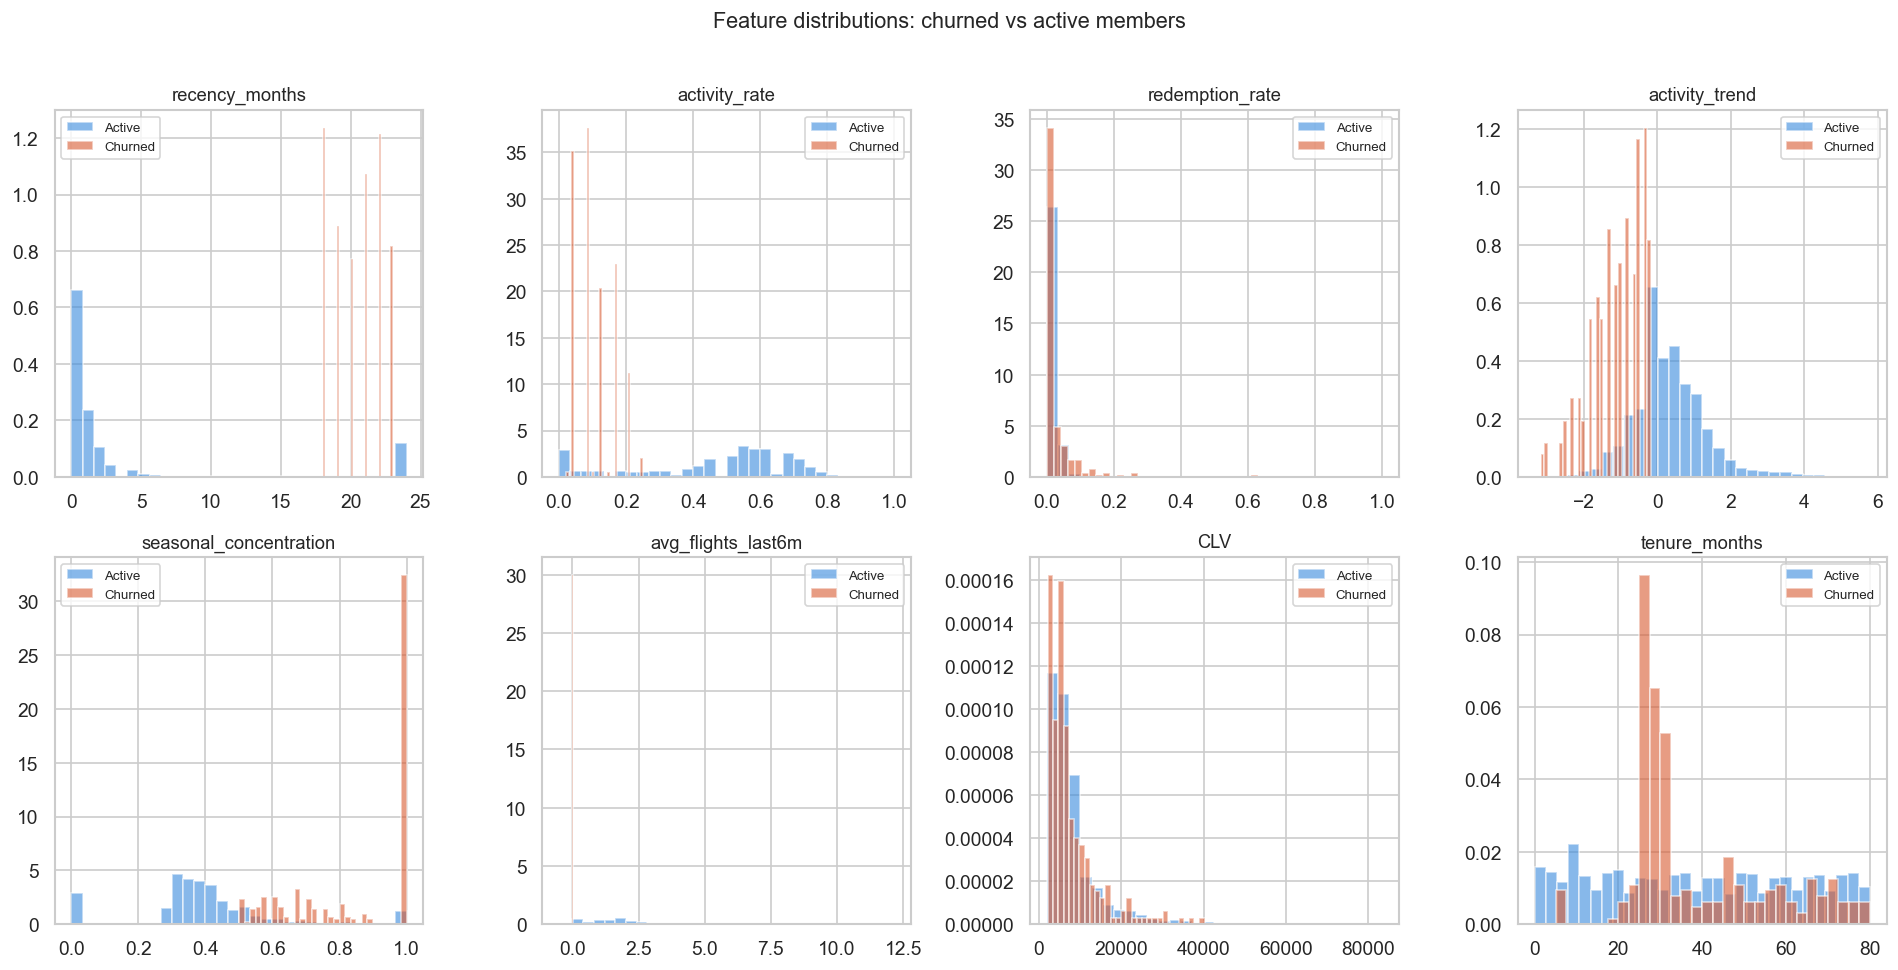

Saved → reports/figures/05_feature_distributions.png


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

plot_features = [
    "recency_months", "activity_rate", "redemption_rate",
    "activity_trend", "seasonal_concentration", "avg_flights_last6m",
    "CLV", "tenure_months"
]

for i, feat in enumerate(plot_features):
    churned     = master[master["churned_behavioral"] == 1][feat].dropna()
    not_churned = master[master["churned_behavioral"] == 0][feat].dropna()
    axes[i].hist(not_churned, bins=30, alpha=0.6, color="#378ADD", label="Active", density=True)
    axes[i].hist(churned,     bins=30, alpha=0.6, color="#D85A30", label="Churned", density=True)
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle("Feature distributions: churned vs active members", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_feature_distributions.png", bbox_inches="tight")
plt.show()
print("Saved → reports/figures/05_feature_distributions.png")


## 12. Save master feature table

In [13]:
out_path = PROC / "master_features.csv"
master.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Shape: {master.shape}")
print()
print("Feature summary:")
print(master[feature_cols].describe().round(2))
print()
print("Notebook 02 complete. Proceed to 03_churn_model.ipynb")


Saved: C:\Users\Madhur Gupta\airline-loyalty-intelligence\data\processed\master_features.csv
Shape: (16737, 38)

Feature summary:
       total_flights  total_distance  total_pts_acc  total_pts_red  \
count       16737.00        16737.00       16737.00       16737.00   
mean           30.40        45579.36       47592.10         734.93   
std            16.87        26092.34       30391.86         716.59   
min             0.00            0.00           0.00           0.00   
25%            20.00        28495.00       28718.00           0.00   
50%            34.00        49445.00       49885.00         568.00   
75%            42.00        62911.00       63812.00        1167.00   
max           106.00       178858.00      268287.00        4479.00   

       months_with_flights  activity_rate  recency_months  redemption_rate  \
count             16737.00       16737.00        16737.00         16737.00   
mean                 10.68           0.46            3.56             0.02   
std  